In [1]:
import torch

# Get the pre-installed PyTorch version
TORCH = torch.__version__.split('+')[0]  ## 2.4.0+cu121 or 2.3.1+cpu to the nice 2.10.0 version output.
CUDA = 'cpu' if not torch.cuda.is_available() else f"cu{torch.version.cuda.replace('.', '')}"

print(f"PyTorch Version: {TORCH}")
print(f"CUDA Extension Version: {CUDA}")

# Install PyG dependencies cleanly
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
## The URL forces pip to look inside that exact, dynamically resolved URL path to find pre-compiled binaries matching Colab's backend instance configuration.
## In graph deep learning, molecules have different numbers of atoms (nodes) and bonds (edges). Storing this in standard dense matrices wastes memory on empty space.
## torch-scatter (Optimized Reductions): When an atom gathers information from its neighboring atoms, it performs a aggregation operation (like adding them together or averaging them). In code, this maps to a "scatter-add" operation. torch-scatter provides highly optimized C++/CUDA kernels that can sum features into non-contiguous memory locations simultaneously without bottlenecking your GPU.
## torch-sparse (Sparse Matrix Operations): This package introduces dedicated sparse matrix multiplication routines. It allows PyG to quickly execute matrix operations on the graph's edge_index layout without expanding it out into a huge, memory-heavy grid of zeros.
!pip install torch-geometric deepchem
!pip install rdkit  # Chemistry library used behind the scenes

from torch_geometric.datasets import MoleculeNet

# Download and load the FreeSolv dataset
dataset = MoleculeNet(root='.', name='FreeSolv')

print(f"Dataset length: {len(dataset)}")
print(f"Number of features per atom (node): {dataset.num_node_features}")
print(f"Number of targets to predict: {dataset.num_classes}")
# Extract the first molecule graph
single_molecule = dataset[0]

print("--- Single Molecule Structure ---")
print(single_molecule)
print(dataset.y.shape)
molecule = dataset[13]
print(molecule)


PyTorch Version: 2.10.0
CUDA Extension Version: cpu
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 894.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 28.4 MB/s eta 0:00:00


Processing...


Dataset length: 642
Number of features per atom (node): 9
Number of targets to predict: 485
--- Single Molecule Structure ---
Data(x=[13, 9], edge_index=[2, 26], edge_attr=[26, 3], smiles='CN(C)C(=O)c1ccc(cc1)OC', y=[1, 1])
torch.Size([642, 1])
Data(x=[9, 9], edge_index=[2, 16], edge_attr=[16, 3], smiles='CCCCC(=O)OCC', y=[1, 1])


Done!
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


- Strings are sequential. Thats why both the molecule data was processed and shown.
- One-Hot Encoding / nn.Embedding lookup table : Really important.

In [2]:
print("\n=== Node Features (Atoms) ===")
print(f"Shape of node matrix x: {molecule.x.shape}")
print("First 3 atoms' raw feature vectors:")
print(molecule.x[:3])  # View the features of the first 3 atoms

print("\n=== Edge Index (Bonds) ===")
print(f"Shape of edge index: {molecule.edge_index.shape}")
print("First 8 bond connections (columns):")
print(molecule.edge_index[:, :8])

print("\n=== Target Value ===")
print(f"Hydration Energy of target (y): {molecule.y}")


=== Node Features (Atoms) ===
Shape of node matrix x: torch.Size([9, 9])
First 3 atoms' raw feature vectors:
tensor([[6, 0, 4, 5, 3, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0]])

=== Edge Index (Bonds) ===
Shape of edge index: torch.Size([2, 16])
First 8 bond connections (columns):
tensor([[0, 1, 1, 2, 2, 3, 3, 4],
        [1, 0, 2, 1, 3, 2, 4, 3]])

=== Target Value ===
Hydration Energy of target (y): tensor([[-2.4900]])


In [11]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool
from torch_geometric.nn.norm import BatchNorm
import numpy as np

# 1. Setup Data Loaders (Assuming 'dataset' is your loaded object from DeepChem)
# Shuffle and split into 80% train, 10% val, 10% test
torch.manual_seed(97)
dataset = dataset.shuffle()

train_idx = int(len(dataset) * 0.8)
val_idx = int(len(dataset) * 0.9)

train_dataset = dataset[:train_idx]
val_dataset = dataset[train_idx:val_idx]
test_dataset = dataset[val_idx:]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Define GNN Architecture with Categorical Embedding handles
class FreeSolvEmbeddingGNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        # FreeSolv features are discrete integers. Let's use an embedding layer
        # for the atomic number (handling up to element 100) to map to dense space.
        self.atom_embedding = nn.Embedding(100, hidden_dim)

        # If using the remaining 8 attributes, you'd add linear projection or more embeddings.
        # For simplicity, we'll project the full 9-dim raw vector into dense space cleanly:
        self.feature_projection = nn.Linear(9, hidden_dim)

        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(p=0.25)

        self.bn1 = BatchNorm(hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Cast to float for projection layer, or isolate element token for Embedding
        x = x.to(torch.float32)
        x = self.gelu(self.feature_projection(x))

        # Message passing
        x = self.gelu(self.conv1(x, edge_index))
        x = self.bn1(x)
        x = self.gelu(self.conv2(x, edge_index))
        x = self.bn2(x)
        x = self.conv3(x, edge_index)

        # Pool node features into complete molecular representations
        graph_emb = global_mean_pool(x, batch)
        graph_emb = self.dropout(graph_emb)

        return self.regressor(graph_emb).squeeze(-1)

# 3. Instantiate Engine Elements
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FreeSolvEmbeddingGNN(hidden_dim=64).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()

# 4. Evaluation Function
def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            # Align shapes: out is [batch_size], data.y is [batch_size, 1]
            loss = criterion(out, data.y.squeeze(-1))
            total_loss += loss.item() * data.num_graphs
    return np.sqrt(total_loss / len(loader.dataset)) # Return Root MSE (RMSE)

# 5. Training Loop
print("Starting FreeSolv GNN Training...")
for epoch in range(1, 151):
    model.train()
    loss_all = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.squeeze(-1))
        loss.backward()
        loss_all += loss.item() * data.num_graphs
        optimizer.step()

    train_rmse = np.sqrt(loss_all / len(train_loader.dataset))
    val_rmse = evaluate(val_loader)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

test_rmse = evaluate(test_loader)
print(f"\nFinal Test Set RMSE: {test_rmse:.4f} kcal/mol")

Starting FreeSolv GNN Training...
Epoch 010 | Train RMSE: 2.2511 | Val RMSE: 2.3681
Epoch 020 | Train RMSE: 2.0312 | Val RMSE: 2.8060
Epoch 030 | Train RMSE: 1.7726 | Val RMSE: 2.0528
Epoch 040 | Train RMSE: 1.7753 | Val RMSE: 1.7806
Epoch 050 | Train RMSE: 1.5440 | Val RMSE: 2.0649
Epoch 060 | Train RMSE: 1.6506 | Val RMSE: 2.7255
Epoch 070 | Train RMSE: 1.4903 | Val RMSE: 1.5835
Epoch 080 | Train RMSE: 1.4265 | Val RMSE: 2.8610
Epoch 090 | Train RMSE: 1.4166 | Val RMSE: 1.4078
Epoch 100 | Train RMSE: 1.3209 | Val RMSE: 2.0426
Epoch 110 | Train RMSE: 1.3821 | Val RMSE: 1.9165
Epoch 120 | Train RMSE: 1.2939 | Val RMSE: 1.8449
Epoch 130 | Train RMSE: 1.3883 | Val RMSE: 1.3634
Epoch 140 | Train RMSE: 1.2367 | Val RMSE: 1.9105
Epoch 150 | Train RMSE: 1.3094 | Val RMSE: 1.9648

Final Test Set RMSE: 3.4856 kcal/mol


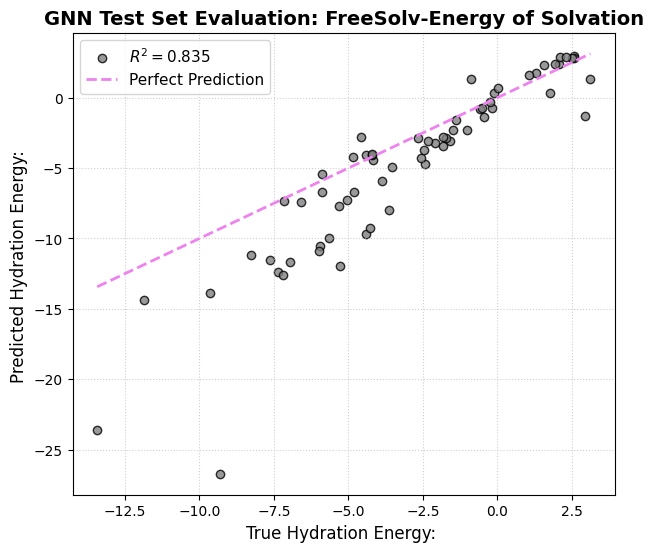

The correlation is strong between data and prediction!


In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(loader, title="Model Predictions vs Ground Truth"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            all_preds.extend(out.view(-1).cpu().numpy())
            all_targets.extend(data.y.view(-1).cpu().numpy())

    # Convert to standard arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate R-squared value to assess the quality of correlation
    correlation_matrix = np.corrcoef(all_targets, all_preds)
    r_squared = correlation_matrix[0, 1] ** 2

    # Generate the scatter plot
    plt.figure(figsize=(7, 6))
    plt.scatter(all_targets, all_preds, alpha=0.8, color='gray', edgecolors='k', label=f'$R^2 = {r_squared:.3f}$')

    # Perfect alignment line (y = x)
    ideal_line = [min(all_targets), max(all_targets)]
    plt.plot(ideal_line, ideal_line, color='violet', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.xlabel("True Hydration Energy: ", fontsize=12)
    plt.ylabel("Predicted Hydration Energy: ", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    if np.sqrt(r_squared) > 0.6:
      print("The correlation is strong between data and prediction!")

# Render the plot for the test set
plot_predictions(test_loader, title="GNN Test Set Evaluation: FreeSolv-Energy of Solvation")
